In [0]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as sf
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
import itertools
from pyspark.sql.functions import col, count, countDistinct, sum as _sum, collect_list, expr

# Iniciar uma sessão Spark
spark = SparkSession.builder \
    .appName("Baralho de Cartas") \
    .getOrCreate()

# Criar listas com os naipes e valores das cartas
naipes = ['Copas', 'Espadas', 'Ouros', 'Paus']
valores = ['A', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'J', 'Q', 'K']

# Criar uma lista para armazenar os dados de todas as cartas
dados_cartas = []

# Preencher a lista com os dados de cada carta
for naipe in naipes:
    # Determinar a cor do naipe
    cor = 'Vermelho' if naipe in ['Copas', 'Ouros'] else 'Preto'
    
    for valor in valores:
        # Definir valor numérico
        if valor == 'A':
            valor_numerico = 1
        elif valor == 'J':
            valor_numerico = 11
        elif valor == 'Q':
            valor_numerico = 12
        elif valor == 'K':
            valor_numerico = 13
        else:
            valor_numerico = int(valor)
        
        # Adicionar carta à lista de dados
        dados_cartas.append((f"{valor} de {naipe}", naipe, valor, valor_numerico, cor))

# Definir o esquema do DataFrame
schema = StructType([
    StructField("Carta", StringType(), False),
    StructField("Naipe", StringType(), False),
    StructField("Valor", StringType(), False),
    StructField("Valor_Numerico", IntegerType(), False),
    StructField("Cor", StringType(), False)
])

# Criar o DataFrame PySpark
baralho_df = spark.createDataFrame(dados_cartas, schema)

# Mostrar o DataFrame
baralho_df.show(52, truncate=False)

+-------------+-------+-----+--------------+--------+
|Carta        |Naipe  |Valor|Valor_Numerico|Cor     |
+-------------+-------+-----+--------------+--------+
|A de Copas   |Copas  |A    |1             |Vermelho|
|2 de Copas   |Copas  |2    |2             |Vermelho|
|3 de Copas   |Copas  |3    |3             |Vermelho|
|4 de Copas   |Copas  |4    |4             |Vermelho|
|5 de Copas   |Copas  |5    |5             |Vermelho|
|6 de Copas   |Copas  |6    |6             |Vermelho|
|7 de Copas   |Copas  |7    |7             |Vermelho|
|8 de Copas   |Copas  |8    |8             |Vermelho|
|9 de Copas   |Copas  |9    |9             |Vermelho|
|10 de Copas  |Copas  |10   |10            |Vermelho|
|J de Copas   |Copas  |J    |11            |Vermelho|
|Q de Copas   |Copas  |Q    |12            |Vermelho|
|K de Copas   |Copas  |K    |13            |Vermelho|
|A de Espadas |Espadas|A    |1             |Preto   |
|2 de Espadas |Espadas|2    |2             |Preto   |
|3 de Espadas |Espadas|3    


## Técnicas de Amostragem

In [0]:
## Amostragem simples sem substituição

baralho_df.sample(withReplacement=False, fraction=0.2).show()

+------------+-------+-----+--------------+--------+
|       Carta|  Naipe|Valor|Valor_Numerico|     Cor|
+------------+-------+-----+--------------+--------+
|  3 de Copas|  Copas|    3|             3|Vermelho|
|  8 de Copas|  Copas|    8|             8|Vermelho|
|  K de Copas|  Copas|    K|            13|Vermelho|
|3 de Espadas|Espadas|    3|             3|   Preto|
|6 de Espadas|Espadas|    6|             6|   Preto|
|8 de Espadas|Espadas|    8|             8|   Preto|
|9 de Espadas|Espadas|    9|             9|   Preto|
|Q de Espadas|Espadas|    Q|            12|   Preto|
|  J de Ouros|  Ouros|    J|            11|Vermelho|
|  Q de Ouros|  Ouros|    Q|            12|Vermelho|
|   A de Paus|   Paus|    A|             1|   Preto|
|   7 de Paus|   Paus|    7|             7|   Preto|
|   9 de Paus|   Paus|    9|             9|   Preto|
|   Q de Paus|   Paus|    Q|            12|   Preto|
+------------+-------+-----+--------------+--------+



In [0]:
## Amostragem simples sem substituição

baralho_df.sample(withReplacement=True, fraction=0.19).show()

+-------------+-------+-----+--------------+--------+
|        Carta|  Naipe|Valor|Valor_Numerico|     Cor|
+-------------+-------+-----+--------------+--------+
|   5 de Copas|  Copas|    5|             5|Vermelho|
|  10 de Copas|  Copas|   10|            10|Vermelho|
|   J de Copas|  Copas|    J|            11|Vermelho|
|   Q de Copas|  Copas|    Q|            12|Vermelho|
|10 de Espadas|Espadas|   10|            10|   Preto|
|   A de Ouros|  Ouros|    A|             1|Vermelho|
|   2 de Ouros|  Ouros|    2|             2|Vermelho|
|   8 de Ouros|  Ouros|    8|             8|Vermelho|
|   J de Ouros|  Ouros|    J|            11|Vermelho|
|    3 de Paus|   Paus|    3|             3|   Preto|
|    6 de Paus|   Paus|    6|             6|   Preto|
+-------------+-------+-----+--------------+--------+



In [0]:
## Amostragem Estratificada

fractions = {"Vermelho": 0.1, "Preto": 0.2}
baralho_df.sampleBy("cor", fractions, seed=42).show()

+------------+-------+-----+--------------+--------+
|       Carta|  Naipe|Valor|Valor_Numerico|     Cor|
+------------+-------+-----+--------------+--------+
|Q de Espadas|Espadas|    Q|            12|   Preto|
|K de Espadas|Espadas|    K|            13|   Preto|
|  8 de Ouros|  Ouros|    8|             8|Vermelho|
|   5 de Paus|   Paus|    5|             5|   Preto|
|   9 de Paus|   Paus|    9|             9|   Preto|
|   J de Paus|   Paus|    J|            11|   Preto|
+------------+-------+-----+--------------+--------+



In [0]:
train, test = baralho_df.randomSplit([0.7, 0.3], seed=42)
print(f'Baralho de teste: \n{test.show()}')
print(f'Baralho de treino: \n{train.show()}')

+-------------+-------+-----+--------------+--------+
|        Carta|  Naipe|Valor|Valor_Numerico|     Cor|
+-------------+-------+-----+--------------+--------+
|   4 de Copas|  Copas|    4|             4|Vermelho|
|  10 de Copas|  Copas|   10|            10|Vermelho|
|   Q de Copas|  Copas|    Q|            12|Vermelho|
| 2 de Espadas|Espadas|    2|             2|   Preto|
| 3 de Espadas|Espadas|    3|             3|   Preto|
| 5 de Espadas|Espadas|    5|             5|   Preto|
| A de Espadas|Espadas|    A|             1|   Preto|
|10 de Espadas|Espadas|   10|            10|   Preto|
| 7 de Espadas|Espadas|    7|             7|   Preto|
|   5 de Ouros|  Ouros|    5|             5|Vermelho|
|   6 de Ouros|  Ouros|    6|             6|Vermelho|
|   9 de Ouros|  Ouros|    9|             9|Vermelho|
|    3 de Paus|   Paus|    3|             3|   Preto|
|    A de Paus|   Paus|    A|             1|   Preto|
|   K de Ouros|  Ouros|    K|            13|Vermelho|
|    5 de Paus|   Paus|    5

In [0]:
baralho_df

Out[24]: DataFrame[Carta: string, Naipe: string, Valor: string, Valor_Numerico: int, Cor: string]

In [0]:
total_cartas = baralho_df.count()
prob_as_copas = baralho_df.filter((sf.col("Valor") == "A") & (sf.col("Naipe") == "Copas")).count() / total_cartas
print(f"Probabilidade de sair Ás de Copas: {prob_as_copas:.2%}")

Probabilidade de sair Ás de Copas: 1.92%


In [0]:
prob_por_naipe = baralho_df.groupBy("Naipe").agg(
    (sf.count("*") / total_cartas).alias("Probabilidade"))

prob_por_naipe.show()

+-------+-------------+
|  Naipe|Probabilidade|
+-------+-------------+
|  Copas|         0.25|
|Espadas|         0.25|
|  Ouros|         0.25|
|   Paus|         0.25|
+-------+-------------+



In [0]:
prob_figura = baralho_df.filter(sf.col("Valor").isin(["K", "Q", "J"])).count() / total_cartas

print(f"Probabilidade de sair uma figura: {prob_figura:.2%}")

Probabilidade de sair uma figura: 23.08%


In [0]:
prob_por_valor = baralho_df.groupBy("Valor_Numerico").agg(
    (sf.count("*") / total_cartas).alias("Probabilidade"))

prob_por_valor.orderBy("Valor_Numerico").show()

+--------------+-------------------+
|Valor_Numerico|      Probabilidade|
+--------------+-------------------+
|             1|0.07692307692307693|
|             2|0.07692307692307693|
|             3|0.07692307692307693|
|             4|0.07692307692307693|
|             5|0.07692307692307693|
|             6|0.07692307692307693|
|             7|0.07692307692307693|
|             8|0.07692307692307693|
|             9|0.07692307692307693|
|            10|0.07692307692307693|
|            11|0.07692307692307693|
|            12|0.07692307692307693|
|            13|0.07692307692307693|
+--------------+-------------------+



## Análises mão de poker

In [0]:
def is_par(df_mao):
    contagem_valores = df_mao.groupBy("Valor").agg(count("*").alias("count"))
    return contagem_valores.filter(col("count") >= 2).count() >= 1

def is_dois_pares(df_mao):
    contagem_valores = df_mao.groupBy("Valor").agg(count("*").alias("count"))
    return contagem_valores.filter(col("count") >= 2).count() >= 2

def is_trinca(df_mao):
    contagem_valores = df_mao.groupBy("Valor").agg(count("*").alias("count"))
    return contagem_valores.filter(col("count") >= 3).count() >= 1

def is_straight(df_mao):
    valores_unicos = sorted([row.Valor_Numerico for row in df_mao.select("Valor_Numerico").distinct().collect()])
    if len(valores_unicos) < 5:
        return False
    
    # Verificar sequência de 5 cartas
    for i in range(len(valores_unicos) - 4):
        if valores_unicos[i+4] - valores_unicos[i] == 4:
            return True
    
    # Caso especial: Ás pode ser alto ou baixo (A-2-3-4-5)
    if set([1, 2, 3, 4, 5]).issubset(valores_unicos):
        return True
    
    return False

def is_flush(df_mao):
    contagem_naipes = df_mao.groupBy("Naipe").agg(count("*").alias("count"))
    return contagem_naipes.filter(col("count") >= 5).count() >= 1

def is_full_house(df_mao):
    # Contar ocorrências de cada valor
    contagem_valores = df_mao.groupBy("Valor").agg(count("*").alias("count")).orderBy(col("count").desc())
    
    # Coletar as contagens como inteiros
    contagens = [int(row['count']) for row in contagem_valores.collect()]
    
    # Verificar se temos pelo menos uma trinca e um par
    if len(contagens) >= 2:
        return contagens[0] >= 3 and contagens[1] >= 2
    return False

def is_quadra(df_mao):
    contagem_valores = df_mao.groupBy("Valor").agg(count("*").alias("count"))
    return contagem_valores.filter(col("count") >= 4).count() >= 1

def is_straight(df_mao):
    valores = [row.Valor_Numerico for row in df_mao.select("Valor_Numerico").distinct().collect()]
    valores_set = set(valores)
    
    straight_sequences = [
        {1, 2, 3, 4, 5},  # Ás baixo
        {2, 3, 4, 5, 6},
        {3, 4, 5, 6, 7},
        {4, 5, 6, 7, 8},
        {5, 6, 7, 8, 9},
        {6, 7, 8, 9, 10},
        {7, 8, 9, 10, 11},  # 7-8-9-10-J
        {8, 9, 10, 11, 12}, # 8-9-10-J-Q
        {9, 10, 11, 12, 13}, # 9-10-J-Q-K
        {10, 11, 12, 13, 1}  # 10-J-Q-K-Ás (Ás alto)
    ]
    
    for seq in straight_sequences:
        if seq.issubset(valores_set):
            return True
    
    return False

def is_royal_flush(df_mao):
    if not is_straight_flush(df_mao):
        return False
    
    naipe_flush = df_mao.groupBy("Naipe").agg(count("*").alias("count")) \
                       .orderBy(col("count").desc()).first().Naipe
    
    valores_royal = {1, 10, 11, 12, 13}  # Ás, 10, Valete, Dama, Rei
    valores_mao = set([row.Valor_Numerico for row in df_mao.filter(col("Naipe") == naipe_flush) \
                                                        .select("Valor_Numerico").collect()])
    
    return valores_royal.issubset(valores_mao)

In [0]:
def avaliar_mao(df_mao):
    # Ordem de classificação das mãos (da melhor para a pior)
    checks = [
        ("Royal Flush", is_royal_flush),
        ("Straight Flush", is_straight_flush),
        ("Quadra", is_quadra),
        ("Full House", is_full_house),
        ("Flush", is_flush),
        ("Straight", is_straight),
        ("Trinca", is_trinca),
        ("Dois Pares", is_dois_pares),
        ("Par", is_par),
        ("Carta Alta", lambda x: True)  
    ]
    
    for nome, funcao in checks:
        if funcao(df_mao):
            return nome

In [0]:
def simular_maos(df_baralho, num_simulacoes, cartas_por_mao=10):
    resultados = []
    
    for _ in range(num_simulacoes):
        # Sortear cartas aleatórias sem reposição
        df_mao = df_baralho.sample(withReplacement=False, fraction=0.5).limit(cartas_por_mao)
        
        # Avaliar a mão
        resultado = avaliar_mao(df_mao)
        resultados.append(resultado)
    
    # Criar DataFrame com resultados
    df_resultados = spark.createDataFrame([(r,) for r in resultados], ["Mao"])
    
    # Calcular probabilidades
    df_probabilidades = df_resultados.groupBy("Mao").agg(
        (count("*") / num_simulacoes).alias("Probabilidade")
    ).orderBy("Probabilidade", ascending=False)
    
    return df_probabilidades

In [0]:
from pyspark.sql.functions import rand

def simular_maos_ultrarapida(df_baralho, num_simulacoes=10000, cartas_por_mao=10):
    # Cache CRUCIAL para performance
    df_baralho = df_baralho.cache()
    
    # 1. Pré-atribuir números aleatórios a todas as cartas
    df_com_rand = df_baralho.withColumn("rand", rand())
    
    # 2. Gerar IDs de simulação (0 a num_simulacoes-1)
    df_simulacoes = spark.range(num_simulacoes).toDF("simulacao_id")
    
    # 3. Join cartas com simulações usando hash determinístico
    cross_df = df_simulacoes.crossJoin(df_com_rand.withColumn(
        "hash_simulacao", 
        F.abs(F.hash(F.concat(F.col("simulacao_id"), F.col("rand")))) % 1000
    ))
    
    # 4. Rankear cartas por simulacao_id
    window = Window.partitionBy("simulacao_id").orderBy("hash_simulacao")
    df_ranked = cross_df.withColumn("rank", F.row_number().over(window))
    
    # 5. Filtrar top N cartas por simulação
    df_maos = df_ranked.filter(F.col("rank") <= cartas_por_mao)
    
    # 6. Agrupar e avaliar
    resultados = df_maos.groupBy("simulacao_id").agg(
        F.collect_list(F.struct("Carta", "Naipe", "Valor", "Valor_Numerico", "Cor")).alias("mao")
    ).rdd.map(lambda x: avaliar_mao(spark.createDataFrame(x.mao))).collect()
    
    # 7. Calcular probabilidades
    df_prob = spark.createDataFrame([(r, 1) for r in resultados], ["Mao", "cnt"])
    df_prob = df_prob.groupBy("Mao").agg(
        (F.sum("cnt") / num_simulacoes).alias("Probabilidade")
    ).orderBy("Probabilidade", ascending=False)
    
    df_baralho.unpersist()
    return df_prob

In [0]:
df_probabilidades = simular_maos(baralho_df, num_simulacoes=100, cartas_por_mao=10)

+--------------+-------------+
|Mao           |Probabilidade|
+--------------+-------------+
|Flush         |0.71         |
|Straight Flush|0.23         |
|Royal Flush   |0.03         |
|Straight      |0.02         |
|Par           |0.01         |
+--------------+-------------+

              Mao  Probabilidade
0           Flush           0.71
1  Straight Flush           0.23
2     Royal Flush           0.03
3        Straight           0.02
4             Par           0.01


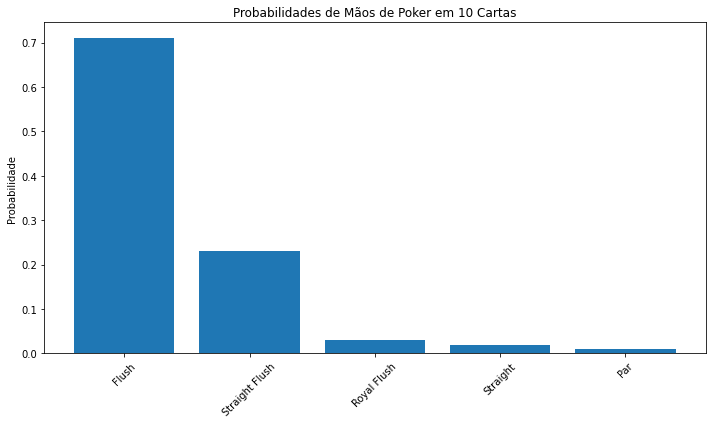

In [0]:
# Executar simulação com 10.000 repetições para maior precisão

# Mostrar resultados
df_probabilidades.show(truncate=False)

# Converter para Pandas para visualização (opcional)
pd_probabilidades = df_probabilidades.toPandas()
print(pd_probabilidades)

# Plotar resultados
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(pd_probabilidades["Mao"], pd_probabilidades["Probabilidade"])
plt.xticks(rotation=45)
plt.ylabel("Probabilidade")
plt.title("Probabilidades de Mãos de Poker em 10 Cartas")
plt.tight_layout()
plt.show()